<a href="https://colab.research.google.com/github/kganitis/FilmRecAI/blob/main/FilmRecAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Choose initial values for R_min and R_max



In [4]:
R_min = 90  # Minimum required number of ratings per user
R_max = 100  # Maximum allowed number of ratings per user

# Data Preprocessing

## Find Unique Users and Movies Sets

* Load the dataset from dataset.npy


In [13]:
dataset = np.load('/content/drive/MyDrive/Colab Notebooks/dataset.npy', encoding='bytes')

In [14]:
dataset

array(['ur4592644,tt0120884,10,16 January 2005',
       'ur3174947,tt0118688,3,16 January 2005',
       'ur3780035,tt0387887,8,16 January 2005', ...,
       'ur4592639,tt0107423,9,16 January 2005',
       'ur4581944,tt0102614,8,16 January 2005',
       'ur1162550,tt0325596,7,16 January 2005'], dtype='<U43')

* Split each row of data into username, movie, rating, and date

In [16]:
data_split = [row.split(',') for row in dataset]

In [24]:
data_split[:5]

[['ur4592644', 'tt0120884', '10', '16 January 2005'],
 ['ur3174947', 'tt0118688', '3', '16 January 2005'],
 ['ur3780035', 'tt0387887', '8', '16 January 2005'],
 ['ur4592628', 'tt0346491', '1', '16 January 2005'],
 ['ur3174947', 'tt0094721', '8', '16 January 2005']]

* Convert data into a pandas DataFrame

In [18]:
df = pd.DataFrame(data_split, columns=['username', 'movie', 'rating', 'date'])

* Convert types: username to string, movie to string, rating to int, date to datetime

In [20]:
df['username'] = df['username'].astype(str)
df['movie'] = df['movie'].astype(str)
df['rating'] = df['rating'].astype(int)
df['date'] = pd.to_datetime(df['date'])

In [23]:
df

,username,movie,rating,date
0,ur4592644,tt0120884,10,2005-01-16
1,ur3174947,tt0118688,3,2005-01-16
2,ur3780035,tt0387887,8,2005-01-16
3,ur4592628,tt0346491,1,2005-01-16
4,ur3174947,tt0094721,8,2005-01-16
...,...,...,...,...
4669815,ur0581842,tt0107977,6,2005-01-16
4669816,ur3174947,tt0103776,8,2005-01-16
4669817,ur4592639,tt0107423,9,2005-01-16
4669818,ur4581944,tt0102614,8,2005-01-16


* Find the sets of unique users and movies

In [25]:
unique_users = df['username'].unique()
unique_movies = df['movie'].unique()

In [26]:
N = len(unique_users)
M = len(unique_movies)

In [27]:
print("Number of Unique Users (U):", N)
print("Number of Unique Movies (I):", M)

Number of Unique Users (U): 1499238
Number of Unique Movies (I): 351109


## Filter Users based on Number of Ratings

Calculate the number of ratings per user

In [28]:
ratings_per_user = df.groupby('username')['rating'].count()

In [37]:
ratings_per_user

username
ur0000001      1
ur0000002      8
ur0000005      3
ur0000011     62
ur0000013      1
              ..
ur9999940      1
ur99999434     1
ur99999655     1
ur99999734    25
ur9999988      1
Name: rating, Length: 1499238, dtype: int64

Define the bins for different ranges of reviews per user

In [35]:
bins = [1, R_min, R_max+1, float('inf')]

In [36]:
bins

[1, 90, 101, inf]

Create labels for the bins

In [30]:
labels = [f'1-{R_min-1}', f'{R_min}-{R_max}', f'{R_max+1}+']

In [34]:
labels

['1-89', '90-100', '101+']

Cut the the number of ratings per user into bins

In [31]:
ratings_bins = pd.cut(ratings_per_user, bins=bins, labels=labels, right=False)

In [38]:
ratings_bins

username
ur0000001     1-89
ur0000002     1-89
ur0000005     1-89
ur0000011     1-89
ur0000013     1-89
              ... 
ur9999940     1-89
ur99999434    1-89
ur99999655    1-89
ur99999734    1-89
ur9999988     1-89
Name: rating, Length: 1499238, dtype: category
Categories (3, object): ['1-89' < '90-100' < '101+']

Count the frequency of users in each bin

In [32]:
bin_counts = ratings_bins.value_counts().sort_index()

In [39]:
bin_counts

rating
1-89      1495677
90-100        408
101+         3153
Name: count, dtype: int64

Filter users based on the number of ratings

In [41]:
filtered_users = ratings_per_user[(ratings_per_user >= R_min) & (ratings_per_user <= R_max)]

In [42]:
filtered_users

username
ur0005684      93
ur0016317      95
ur0020028     100
ur0041696      96
ur0048735      99
             ... 
ur98975951     97
ur99448052     90
ur99460682     96
ur99877336     93
ur99907711     90
Name: rating, Length: 408, dtype: int64

Filter the DataFrame based on the filtered users

In [43]:
filtered_df = df[df['username'].isin(filtered_users.index)]

In [44]:
filtered_df

,username,movie,rating,date
149,ur1907398,tt0339291,9,2005-01-16
152,ur1907398,tt0290002,6,2005-01-16
153,ur1907398,tt0362270,8,2005-01-16
156,ur1907398,tt0338751,9,2005-01-16
272,ur1637337,tt0072502,7,2005-01-16
...,...,...,...,...
4669708,ur4067801,tt0111257,9,2005-01-15
4669719,ur4067801,tt0301083,9,2005-01-15
4669722,ur4067801,tt0117913,9,2005-01-15
4669729,ur4067801,tt0120179,2,2005-01-15


Get the sets of filtered users and movies

In [45]:
filtered_unique_users = filtered_df['username'].unique()
filtered_unique_movies = filtered_df['movie'].unique()

In [46]:
n = len(filtered_unique_users)
m = len(filtered_unique_movies)

In [47]:
print("R_min:", R_min)
print("R_max:", R_max)
print("Number of Filtered Users (Û):", n)
print("Number of Filtered Movies (Î):", m)

R_min: 90
R_max: 100
Number of Filtered Users (Û): 408
Number of Filtered Movies (Î): 20767


## Generate Frequency Histograms

Recalculate the number of ratings per user based on the filtered DataFrame

In [48]:
ratings_per_user_filtered = filtered_df.groupby('username')['rating'].count()

First Histogram: Number of Ratings per User

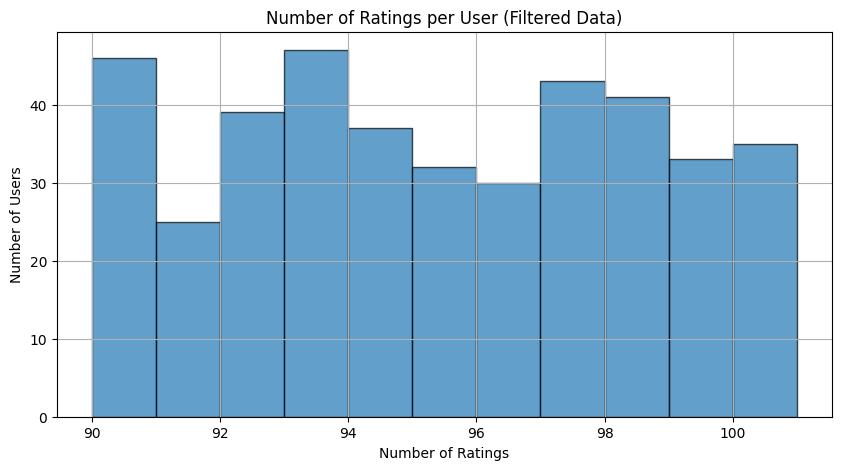

In [60]:
plt.figure(figsize=(10, 5))
plt.hist(ratings_per_user_filtered, bins=range(R_min, R_max + 2), edgecolor='black', alpha=0.7)
plt.title('Number of Ratings per User (Filtered Data)')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.grid(True)
plt.show()

Calculate time ranges (in days) for each user based on the filtered DataFrame


In [65]:
first_rating_dates = filtered_df.groupby('username')['date'].min()
last_rating_dates = filtered_df.groupby('username')['date'].max()
time_ranges = (last_rating_dates - first_rating_dates).dt.days

Second Histogram: Time Ranges for All Ratings by Users (Filtered Data)

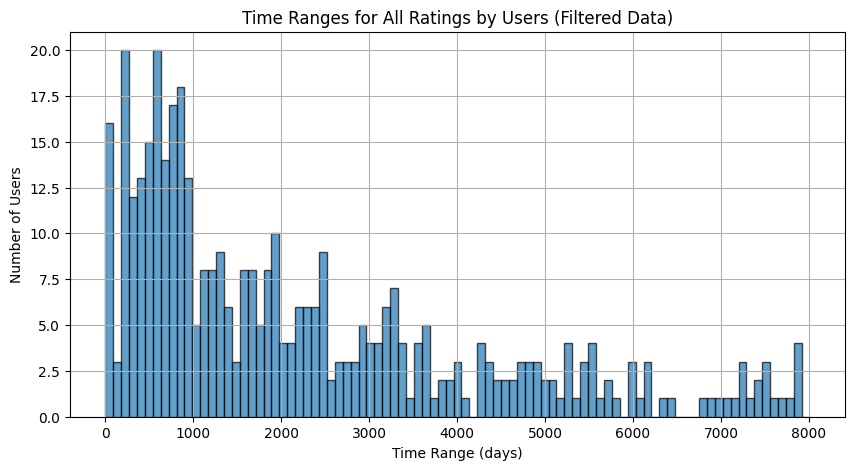

In [69]:
plt.figure(figsize=(10, 5))
plt.hist(time_ranges, bins=range(0, max(time_ranges) + 8, 90), edgecolor='black', alpha=0.7)
plt.title('Time Ranges for All Ratings by Users (Filtered Data)')
plt.xlabel('Time Range (days)')
plt.ylabel('Number of Users')
plt.grid(True)
plt.show()

## Generate Preference (Feature) Vectors for each User

Use a pivot table to aggregate duplicate ratings by taking the maximum rating for each user-movie combination

In [70]:
pivot_df = filtered_df.pivot_table(index='username', columns='movie', values='rating', aggfunc='last')

In [71]:
pivot_df

movie,tt0000012,tt0000091,tt0000417,tt0000439,tt0001223,tt0002130,tt0003489,tt0004972,tt0005680,tt0005960,...,tt9879078,tt9883042,tt9894470,tt9898836,tt9898858,tt9900782,tt9906260,tt9906644,tt9908860,tt9916270
username,,,,,,,,,,,,,,,,,,,,,
ur0005684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ur0016317,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ur0020028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ur0041696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ur0048735,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ur98975951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ur99448052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ur99460682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Fill missing values (movies not rated by users) with 0

In [72]:
pivot_df.fillna(0, inplace=True)

In [73]:
pivot_df

movie,tt0000012,tt0000091,tt0000417,tt0000439,tt0001223,tt0002130,tt0003489,tt0004972,tt0005680,tt0005960,...,tt9879078,tt9883042,tt9894470,tt9898836,tt9898858,tt9900782,tt9906260,tt9906644,tt9908860,tt9916270
username,,,,,,,,,,,,,,,,,,,,,
ur0005684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur0016317,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur0020028,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur0041696,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur0048735,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ur98975951,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur99448052,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur99460682,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Sort the pivot table so that the users with the most ratings appear in the first rows and the most rated movies in the first columns

In [78]:
ratings_per_user_filtered = filtered_df.groupby('username')['rating'].count()
sorted_users = ratings_per_user_filtered.sort_values(ascending=False).index
pivot_df = pivot_df.loc[sorted_users]

ratings_count_movies = filtered_df.groupby('movie')['rating'].count()
sorted_movies = ratings_count_movies.sort_values(ascending=False).index
pivot_df = pivot_df[sorted_movies]

In [79]:
pivot_df

movie,tt7286456,tt4154796,tt0468569,tt2527338,tt6751668,tt0816692,tt7131622,tt2488496,tt8946378,tt0372784,...,tt0314465,tt0314498,tt0314630,tt0314786,tt0314979,tt0315008,tt0315064,tt0315110,tt0315232,tt9916270
username,,,,,,,,,,,,,,,,,,,,,
ur21641070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur116641944,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur102566098,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur87042890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur97483631,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ur13650798,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur13258440,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ur6808754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Convert the pivot table to a numpy array of preference vectors

In [80]:
preference_vectors = pivot_df.values

In [81]:
preference_vectors

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [10.,  9.,  0., ...,  0.,  0.,  0.]])